# FIFA World Cup 2026 — Set-Piece Analysis
### Corners in All Games: Group Stage vs Knockout Stage

**Course task:** Analytic Task — Python-based data analysis of a FIFA World Cup 2026 dataset.

This notebook performs **one complete analytic task** on the *Corners in All Games: Group Stage vs Knockout Stage* dataset, covering all six required skills:

1. Analytic question formulation
2. Data wrangling
3. Data preparation and sampling
4. Descriptive statistics
5. Inferential statistics — Confidence Interval
6. Inferential statistics — One-Sample t-Test (paired-difference form)

Charts are included throughout to make each step easy to follow.

**Distinctness from the previous tasks:** the earlier notebooks investigated *individual players' goal-scoring* and *team yellow cards*. This notebook investigates a different focal point — **team-level corner kicks across all World Cup games** — so it is a genuinely different analytic task.

## 1. Analytic Question Formulation

**Focal point of investigation:** whether teams win a different number of corner kicks in the **Group Stage** compared with the **Knockout Stage**, counting every World Cup match they played.

> **Analytic question:** *Among teams that qualified for the Knockout Stage of the FIFA World Cup 2026, is there a statistically significant difference between the total number of corners a team wins in the Group Stage and the total number it wins in the Knockout Stage?*

**Why this matters:** Corners are a repeatable attacking outcome: they reflect territorial pressure and wide play. Knockout football is often tighter and more conservative, which could reduce corners; alternatively, extra-time matches and desperate late attacks could increase them. Group Stage totals also cover a guaranteed three matches, while knockout totals depend on how far a team progresses. This task tests whether those competing effects leave a detectable stage gap in the 2026 data.

We use a **paired comparison**: each qualifying team supplies two linked measurements — its Group Stage total and its Knockout Stage total — so each team acts as its own control, isolating the *stage effect* from team-to-team differences in playing style.

## 2. Data Wrangling

The file `Corners_by_Team.xlsx` was scraped from FBref match reports (the Team Stats Extra box on each World Cup game page) using the Python library `soccerdata`. It lists every one of the 48 competing nations, with the number of corner kicks it won in the **Group Stage**, the **Knockout Stage**, and a **Grand Total**.

Steps:
- Load the spreadsheet.
- Standardise column names.
- Check data types and missing values.
- Interpret missing `Knockout` values correctly (see below).
- Verify internal consistency (`Group Stage + Knockout == Grand Total`).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Reproducibility
RNG_SEED = 42
np.random.seed(RNG_SEED)

# Consistent chart style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df_raw = pd.read_excel('Corners_by_Team.xlsx')
print('Rows, columns:', df_raw.shape)
df_raw.head()

Rows, columns: (48, 4)


,Teams,Group Stage,Knockout,Grand Total
0,Algeria,12,2.0,14
1,Argentina,9,32.0,41
2,Australia,12,4.0,16
3,Austria,10,0.0,10
4,Belgium,14,10.0,24


In [2]:
# Standardise column names
df = df_raw.rename(columns={
    'Teams': 'team',
    'Group Stage': 'group_stage_corners',
    'Knockout': 'knockout_corners',
    'Grand Total': 'total_corners'
}).copy()

print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())

team                       str
group_stage_corners      int64
knockout_corners       float64
total_corners            int64
dtype: object

Missing values per column:
team                    0
group_stage_corners     0
knockout_corners       16
total_corners           0
dtype: int64


**Interpreting the missing knockout values:** the FIFA World Cup 2026 expanded format has 48 teams; only the 32 teams that finish top of their group (or as one of the best third-placed teams) advance to the Knockout Stage. A `NaN` in the knockout column therefore does **not** mean the data is missing by error — it means the team was eliminated in the Group Stage and never played a Knockout Stage match, so it structurally cannot have a Knockout Stage observation. We keep this distinction explicit (rather than silently filling with 0) because it directly defines our population for this task.

In [3]:
# Consistency check, treating a structural NaN (team eliminated in group stage) as 0 knockout matches
df['knockout_corners_filled'] = df['knockout_corners'].fillna(0)
mismatch = df[df['group_stage_corners'] + df['knockout_corners_filled'] != df['total_corners']]
print(f'Rows where Group Stage + Knockout != Grand Total: {len(mismatch)}')

n_eliminated = df['knockout_corners'].isna().sum()
n_qualified = df['knockout_corners'].notna().sum()
print(f'\nTotal teams in the file        : {len(df)}')
print(f'Teams eliminated in Group Stage : {n_eliminated}')
print(f'Teams that reached Knockout     : {n_qualified}')

Rows where Group Stage + Knockout != Grand Total: 0

Total teams in the file        : 48
Teams eliminated in Group Stage : 16
Teams that reached Knockout     : 32


## 3. Data Preparation and Sampling

**Population:** all FIFA World Cup 2026 teams that reached the Knockout Stage (N = 32). Only these teams have a genuine, comparable pair of measurements (`group_stage_corners`, `knockout_corners`); teams eliminated in the Group Stage are excluded, since they have no Knockout Stage observation to pair against.

**Variable of interest for inference:** the **per-team difference**
`diff = group_stage_corners − knockout_corners`

**Sampling technique:** the population of 32 qualifying teams is itself small, but to properly demonstrate the sampling and inference skills we draw a **Simple Random Sample (SRS) without replacement** of `n = 20` teams (62.5% of the population) using a fixed random seed for reproducibility. With such a small population, a t-based confidence interval and t-test still apply, provided the sampled differences are reasonably symmetric/unimodal — we check this with a histogram in the next section.

In [4]:
population = df[df['knockout_corners'].notna()].reset_index(drop=True)
population['knockout_corners'] = population['knockout_corners'].astype(int)

SAMPLE_SIZE = 20
sample = population.sample(n=SAMPLE_SIZE, random_state=RNG_SEED).reset_index(drop=True)
sample['diff'] = sample['group_stage_corners'] - sample['knockout_corners']

print(f'Population size (teams reaching Knockout): {len(population)}')
print(f'Sample size: {len(sample)}')
sample[['team', 'group_stage_corners', 'knockout_corners', 'diff']].head(10)

Population size (teams reaching Knockout): 32
Sample size: 20


,team,group_stage_corners,knockout_corners,diff
0,Sweden,17,1,16
1,England,24,16,8
2,Paraguay,2,8,-6
3,Germany,18,16,2
4,Canada,35,15,20
5,Colombia,14,10,4
6,Switzerland,19,9,10
7,Portugal,10,12,-2
8,Côte d'Ivoire,12,14,-2
9,Algeria,12,2,10


## 4. Descriptive Statistics

We summarise the sample distributions of Group Stage corners, Knockout Stage corners, and the paired difference.

In [5]:
desc = sample[['group_stage_corners', 'knockout_corners', 'diff']].describe().T
desc['skew'] = sample[['group_stage_corners', 'knockout_corners', 'diff']].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
group_stage_corners,20.0,14.65,6.861602,2.0,11.50,14.0,17.25,35.0,1.197474
knockout_corners,20.0,10.90,9.497368,0.0,3.75,9.5,15.00,36.0,1.425507
diff,20.0,3.75,11.106541,-23.0,-1.25,6.0,10.00,20.0,-1.089680


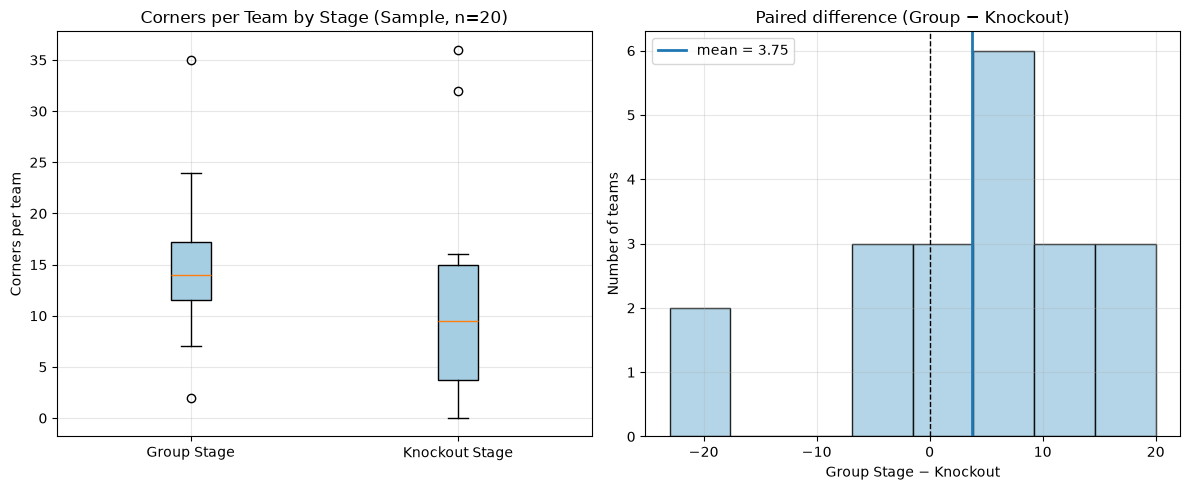

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot comparison
axes[0].boxplot(
    [sample['group_stage_corners'], sample['knockout_corners']],
    tick_labels=['Group Stage', 'Knockout Stage'],
    patch_artist=True,
    boxprops=dict(facecolor='#a6cee3')
)
axes[0].set_title('Corners per Team by Stage (Sample, n=20)')
axes[0].set_ylabel('Corners per team')

# Histogram of paired differences
axes[1].hist(sample['diff'], bins=8, color='#a6cee3', edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(sample['diff'].mean(), color='#1f78b4', linewidth=2, label=f"mean = {sample['diff'].mean():.2f}")
axes[1].set_title('Paired difference (Group − Knockout)')
axes[1].set_xlabel('Group Stage − Knockout')
axes[1].set_ylabel('Number of teams')
axes[1].legend()
plt.tight_layout()
plt.show()

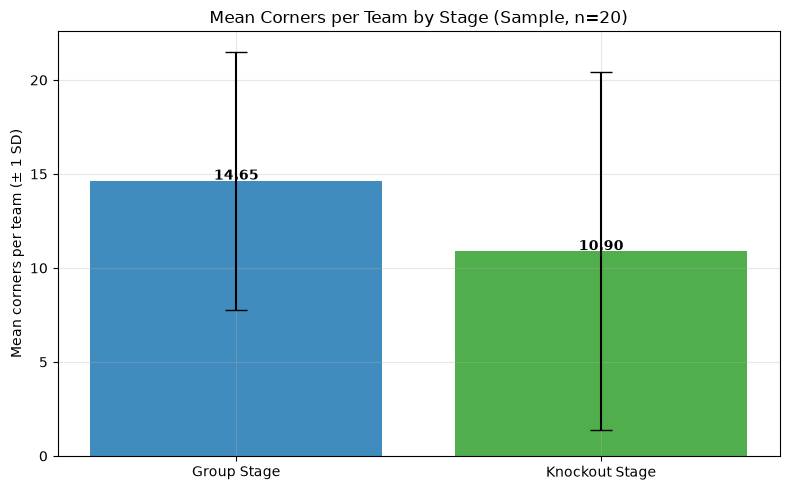

Sample mean — Group Stage corners : 14.650
Sample mean — Knockout corners    : 10.900
Sample mean — Difference        : 3.750
Sample std  — Difference        : 11.107


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
means = [sample['group_stage_corners'].mean(), sample['knockout_corners'].mean()]
stds = [sample['group_stage_corners'].std(), sample['knockout_corners'].std()]
ax.bar(['Group Stage', 'Knockout Stage'], means, yerr=stds, capsize=8,
       color=['#1f78b4', '#33a02c'], alpha=0.85)
ax.set_ylabel('Mean corners per team (± 1 SD)')
ax.set_title('Mean Corners per Team by Stage (Sample, n=20)')
for i, m in enumerate(means):
    ax.text(i, m + 0.05, f'{m:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Sample mean — Group Stage corners : {sample['group_stage_corners'].mean():.3f}")
print(f"Sample mean — Knockout corners    : {sample['knockout_corners'].mean():.3f}")
print(f"Sample mean — Difference        : {sample['diff'].mean():.3f}")
print(f"Sample std  — Difference        : {sample['diff'].std():.3f}")

**Interpretation of descriptives:** Compare the two stage means and the histogram of differences. A histogram centred to the right of zero means most sampled teams won more corners in the Group Stage; to the left means the opposite. We also check that the difference distribution is reasonably symmetric/unimodal before relying on a t-interval and t-test.

## 5. Inferential Statistics — Confidence Interval

We estimate, from the sample, a **95% confidence interval for the true population mean paired difference** (Group Stage corners − Knockout Stage corners) among all World Cup 2026 teams that reached the Knockout Stage.

Because the population standard deviation is unknown, we use the **t-distribution** with `n − 1 = 19` degrees of freedom:

$$\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$

In [8]:
n = len(sample)
mean_diff = sample['diff'].mean()
sd_diff = sample['diff'].std(ddof=1)
se_diff = sd_diff / np.sqrt(n)

confidence = 0.95
alpha = 1 - confidence
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

margin_of_error = t_crit * se_diff
ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print(f'Sample mean difference        : {mean_diff:.3f} corners')
print(f'Sample std dev of difference  : {sd_diff:.3f}')
print(f'Standard error                : {se_diff:.3f}')
print(f't critical value (df={n-1})   : {t_crit:.3f}')
print(f'Margin of error               : {margin_of_error:.3f}')
print(f'95% Confidence Interval       : ({ci_lower:.3f}, {ci_upper:.3f})')

Sample mean difference        : 3.750 corners
Sample std dev of difference  : 11.107
Standard error                : 2.483
t critical value (df=19)   : 2.093
Margin of error               : 5.198
95% Confidence Interval       : (-1.448, 8.948)


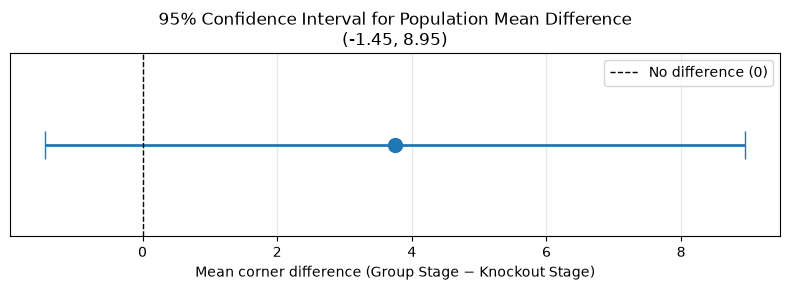

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(mean_diff, 0, xerr=margin_of_error, fmt='o', color='#1f78b4',
            markersize=10, capsize=10, elinewidth=2)
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='No difference (0)')
ax.set_yticks([])
ax.set_xlabel('Mean corner difference (Group Stage − Knockout Stage)')
ax.set_title(f'95% Confidence Interval for Population Mean Difference\n({ci_lower:.2f}, {ci_upper:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** we are 95% confident that the *true mean difference* in corners per team, across the whole population of Knockout Stage-qualifying teams, between the Group Stage and the Knockout Stage lies within the interval above. If the interval **contains 0**, a true mean difference of zero remains plausible at the 95% level. If it **excludes 0**, the data support a systematic stage difference in corners among knockout-qualifying teams.

## 6. Inferential Statistics — One-Sample t-Test (paired-difference form)

We test whether the population mean paired difference is zero.

**Hypotheses**

- $H_0$: $\mu_d = 0$ (no difference in mean corners between stages)
- $H_1$: $\mu_d \neq 0$ (mean Group Stage corners differ from mean Knockout Stage corners)

**Significance level:** $\alpha = 0.05$ (two-tailed)

Because we have one measurement of `diff` per sampled team, this is a **one-sample t-test on the paired differences**, which is equivalent to a paired t-test of Group Stage vs Knockout Stage.

In [10]:
# One-sample t-test on the paired differences, testing against a population mean of 0
t_stat, p_value = stats.ttest_1samp(sample['diff'], popmean=0)

print(f'Test statistic (t)  : {t_stat:.3f}')
print(f'Degrees of freedom   : {n-1}')
print(f'p-value (two-tailed) : {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nDecision: p-value < {alpha}  ->  Reject H0.')
    print('There IS a statistically significant difference between Group Stage and')
    print('Knockout Stage corners per team.')
else:
    print(f'\nDecision: p-value >= {alpha}  ->  Fail to reject H0.')
    print('There is NOT enough evidence of a difference between Group Stage and')
    print('Knockout Stage corners per team.')

Test statistic (t)  : 1.510
Degrees of freedom   : 19
p-value (two-tailed) : 0.1475

Decision: p-value >= 0.05  ->  Fail to reject H0.
There is NOT enough evidence of a difference between Group Stage and
Knockout Stage corners per team.


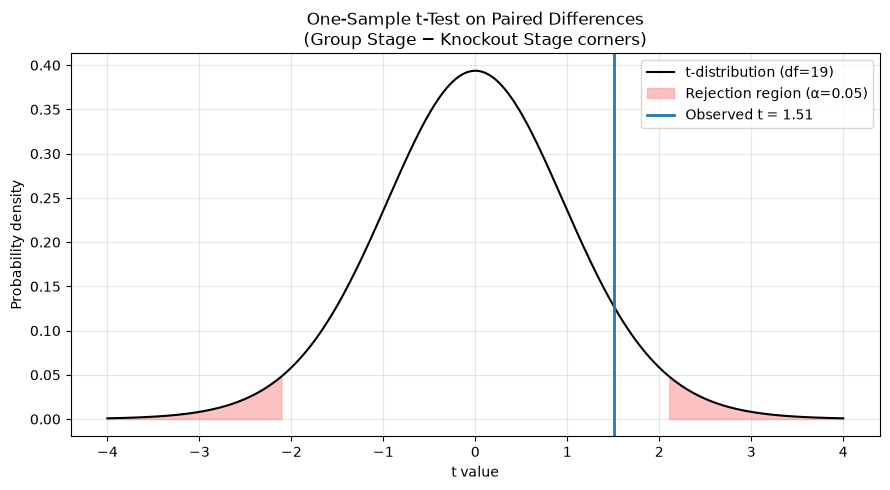

In [11]:
# Visualise the t-distribution, the observed t-statistic, and the rejection region
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, df=n-1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, color='black', linewidth=1.5, label=f't-distribution (df={n-1})')

crit = stats.t.ppf(1 - alpha/2, df=n-1)
ax.fill_between(x, y, where=(x <= -crit), color='#fb9a99', alpha=0.6, label='Rejection region (α=0.05)')
ax.fill_between(x, y, where=(x >= crit), color='#fb9a99', alpha=0.6)

ax.axvline(t_stat, color='#1f78b4', linewidth=2, label=f'Observed t = {t_stat:.2f}')
ax.set_title('One-Sample t-Test on Paired Differences\n(Group Stage − Knockout Stage corners)')
ax.set_xlabel('t value')
ax.set_ylabel('Probability density')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusion

- **Descriptive statistics:** in the sample of 20 knockout-qualifying teams, mean corners were 14.65 in the Group Stage and 10.90 in the Knockout Stage (mean paired difference = 3.75).
- The **95% confidence interval** for the population mean difference is **(-1.45, 8.95)**. Because this interval contains 0, a true mean difference of zero remains plausible.
- The **one-sample t-test on paired differences** gave p = 0.1475. At α = 0.05 we **fail to reject H₀**: there is not enough evidence of a systematic difference between Group Stage and Knockout Stage corner totals among 2026 knockout qualifiers.

**Practical takeaway:** sampled teams won somewhat more corners in the Group Stage, but the gap is not statistically significant. That is consistent with corners being a fairly stable team trait (width, full-back overlap, territorial pressure) that does not jump sharply between stages, even though the number of matches played is not the same.

**Limitations:**
- These figures are **stage totals**, not per-match rates. Teams play three guaranteed Group Stage matches and a variable number of Knockout matches, so a higher Group Stage total can partly reflect extra games rather than a change in intensity.
- The population was restricted to the 32 teams that reached the Knockout Stage; the 16 teams eliminated in the Group Stage could not be included in this paired comparison.
- Match reports were downloaded with the `soccerdata` library (FBref HTML, cached under `~/soccerdata/data/FBref`). Re-opening this notebook only needs `Corners_by_Team.xlsx`.